# DeepTopic motif curation

Review clustered motifs from CREsted MoDISco -> gimme cluster -> TomTom.
Filter by annotation quality, check for redundancy, classify by biological function.
Adapted from `bin/3_single_task_models/6_motif_curation.ipynb` (ChromBPNet).

**Inputs:**
- `crested_model/motifs/meme/combined.meme` — clustered motif PWMs
- `crested_model/motifs/tfs_initial.txt` — TomTom TF annotations

**Outputs:**
- `crested_model/motifs/curation/motif_annotations_full.csv` — all motifs with quality tiers and categories
- `crested_model/motifs/curation/motif_annotations_curated.csv` — filtered set (poor matches and redundant removed)
- `crested_model/motifs/curation/motif_catalog_full.pdf` — visual catalog with logos + annotations

Reference: Nair et al. Section 2.8.1

# Set-up

In [1]:
import os
import numpy as np
import pandas as pd
import logomaker as lm
from tangermeme.io import read_meme

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

LOGO_ALPHABET = 'ACGT'
LOGO_COLORS = {'A': '#109648', 'C': '#255C99', 'G': '#F7B32B', 'T': '#D62839'}

In [2]:
# Paths
dataset = 'sc-islet-differentiation_10X-Multiome'
subset = 'endocrine_replicate'
base_dir = f'/cellar/users/aklie/data/datasets/{dataset}'
results_dir = f'{base_dir}/results/4_topic_models/{subset}'
motif_dir = f'{results_dir}/crested_model/motifs'

path_motif_file = f'{motif_dir}/meme/combined.meme'
path_motif_annotation = f'{motif_dir}/tfs_initial.txt'
path_out = f'{motif_dir}/curation'
os.makedirs(path_out, exist_ok=True)

# Load
motif_dict = read_meme(path_motif_file)
motifs_df = pd.read_csv(path_motif_annotation, sep='\t', header=None, skiprows=0,
                         names=['cluster_name', 'annotation', 'evalue'])

# Derived columns
motifs_df['tf_name'] = motifs_df['annotation'].apply(lambda x: x.split('_')[0].split('.')[0])
motifs_df['source'] = motifs_df['cluster_name'].apply(
    lambda x: 'singleton' if x.startswith('Topic') else 'clustered'
)
motifs_df['log_evalue'] = np.log10(motifs_df['evalue'].clip(lower=1e-30))

# E-value quality tier
motifs_df['quality'] = pd.cut(motifs_df['evalue'],
    bins=[0, 1e-10, 1e-5, 0.01, 0.1, 1, 100],
    labels=['excellent', 'strong', 'moderate', 'weak', 'poor', 'no_match'])

print(f'{len(motifs_df)} motifs loaded')
motifs_df.head()

47 motifs loaded


,cluster_name,annotation,evalue,tf_name,source,log_evalue,quality
0,Average_506,Unknown_no_match,1.000000e+02,Unknown,clustered,2.000000,no_match
1,Average_455,ZN143_MOUSE.H11MO.0.A,3.491540e-24,ZN143,clustered,-23.456983,excellent
2,Average_522,CTCF_MA0139.1,1.086410e-19,CTCF,clustered,-18.964006,excellent
3,Average_503,NFYB_HUMAN.H11MO.0.A,7.941840e-14,NFYB,clustered,-13.100079,excellent
4,Average_497,HNF4A_HUMAN.H11MO.0.A,1.304070e-11,HNF4A,clustered,-10.884699,excellent


# Overview

In [3]:
print('=== Quality tiers ===')
print(motifs_df['quality'].value_counts().sort_index())
print(f'\n=== Source ===')
print(motifs_df['source'].value_counts())

# Duplicate TF families
dupes = motifs_df['tf_name'].value_counts()
dupes = dupes[dupes > 1]
print(f'\n=== {len(dupes)} TF families with multiple motifs ===')
for tf in dupes.index:
    rows = motifs_df[motifs_df['tf_name'] == tf][['cluster_name', 'annotation', 'evalue', 'quality']]
    print(f'\n{tf}:')
    for _, r in rows.iterrows():
        print(f'  {r["cluster_name"]:45s} {r["annotation"]:35s} e={r["evalue"]:.2e} [{r["quality"]}]')

=== Quality tiers ===
excellent     4
strong       11
moderate     13
weak          5
poor          7
no_match      7
Name: quality, dtype: int64

=== Source ===
clustered    37
singleton    10
Name: source, dtype: int64

=== 3 TF families with multiple motifs ===

RFX6:
  Average_500                                   RFX6_MOUSE.H11MO.0.C                e=5.26e-04 [moderate]
  Average_514                                   RFX6_MOUSE.H11MO.0.C                e=4.56e-02 [weak]

HNF6:
  Average_523                                   HNF6_HUMAN.H11MO.0.B                e=4.18e-04 [moderate]
  Average_482                                   HNF6_HUMAN.H11MO.0.B                e=1.22e+00 [no_match]

SP1:
  Average_517                                   SP1_MOUSE.H11MO.0.A                 e=6.11e-07 [strong]
  Topic38.pattern_6.pfm                         SP1_HUMAN.H11MO.0.A                 e=2.76e-03 [moderate]


# Classify motifs by biological function

In [4]:
# Known TF families relevant to islet differentiation
islet_tfs = {
    'endocrine_master': ['PDX1', 'NKX2', 'NKX6', 'PAX6', 'NEUROD', 'NDF', 'RFX6', 'RFX2', 'RFX4', 'ISL1', 'MAFA', 'MAFB'],
    'early_patterning': ['SOX', 'FOXA', 'FOXB', 'HNF1', 'HNF4', 'HNF6', 'GATA', 'CDX2', 'OTX2', 'CEBP', 'COT2'],
    'signaling_effectors': ['TEAD', 'SMAD', 'JUN', 'FOS', 'ATF', 'CREB', 'ETS', 'ETV', 'ELK'],
    'structural': ['CTCF', 'CTCFL', 'REST', 'ZN143', 'NRF1', 'NFY', 'SP1', 'SP2'],
    'cell_cycle': ['FOXM1', 'E2F'],
    'other_developmental': ['TBX', 'SIX', 'BARHL', 'CUX', 'ZIC', 'GRHL', 'ARNTL', 'EVI1'],
}

def classify_motif(tf_name):
    tf_upper = tf_name.upper()
    for category, tfs in islet_tfs.items():
        for tf in tfs:
            if tf.upper() in tf_upper:
                return category
    return 'unclassified'

motifs_df['category'] = motifs_df['tf_name'].apply(classify_motif)

print('=== Motif categories ===')
for cat in list(islet_tfs.keys()) + ['unclassified']:
    rows = motifs_df[motifs_df['category'] == cat]
    if len(rows) > 0:
        print(f'\n{cat} ({len(rows)}):')
        for _, r in rows.iterrows():
            print(f'  {r["tf_name"]:15s} {r["cluster_name"]:45s} e={r["evalue"]:.2e} [{r["quality"]}]')

=== Motif categories ===

endocrine_master (6):
  MAFB            Average_510                                   e=2.42e-09 [strong]
  PAX6            Average_511                                   e=7.08e-09 [strong]
  NDF2            Average_417                                   e=3.48e-08 [strong]
  RFX6            Average_500                                   e=5.26e-04 [moderate]
  PDX1            Average_520                                   e=1.97e-02 [weak]
  RFX6            Average_514                                   e=4.56e-02 [weak]

early_patterning (10):
  HNF4A           Average_497                                   e=1.30e-11 [excellent]
  CEBPA           Average_388                                   e=3.75e-10 [strong]
  FOXA2           Average_475                                   e=1.16e-07 [strong]
  HNF1B           Average_516                                   e=3.08e-06 [strong]
  HNF6            Average_523                                   e=4.18e-04 [moderate]
 

# Full motif catalog with logos

Saved full catalog (47 motifs) with quality indicators
Green=excellent, Blue=strong, Orange=moderate, Red=weak, Gray=poor, Yellow=no_match


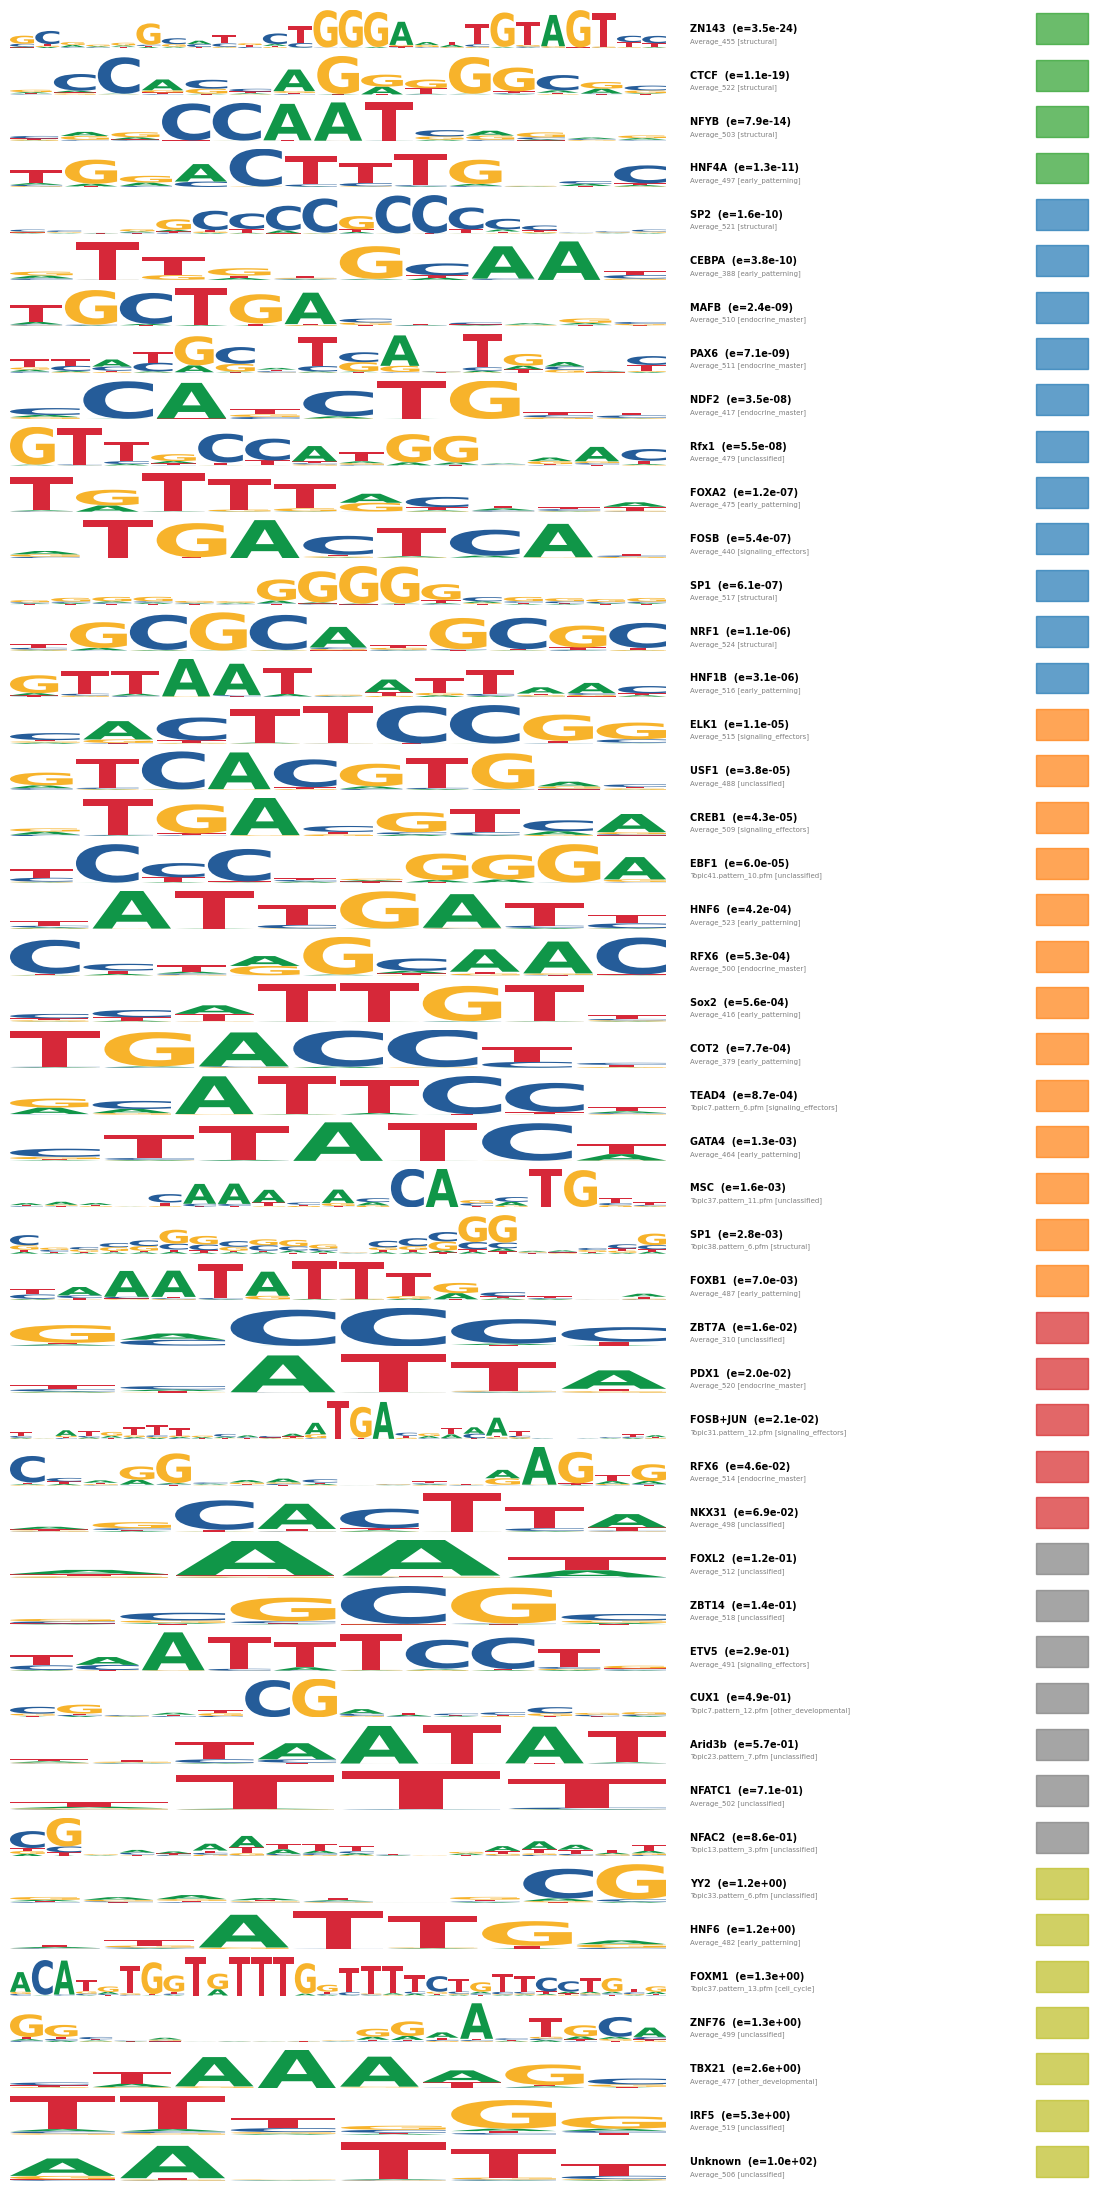

In [5]:
# Sort by e-value
df_sorted = motifs_df.sort_values('evalue').reset_index(drop=True)
n = len(df_sorted)

fig = plt.figure(figsize=(14, n * 0.6), dpi=100)
gs = gridspec.GridSpec(n, 3, width_ratios=[3, 1.5, 0.3], wspace=0.05)

for i, row in df_sorted.iterrows():
    motif_name = row['cluster_name']
    annotation = row['tf_name']
    evalue = row['evalue']
    quality = row['quality']

    qcolor = {'excellent': '#2ca02c', 'strong': '#1f77b4', 'moderate': '#ff7f0e',
              'weak': '#d62728', 'poor': '#7f7f7f', 'no_match': '#bcbd22'}[quality]

    # Logo
    ax_logo = fig.add_subplot(gs[i, 0])
    ppm = motif_dict[motif_name].numpy().T
    lm_df = lm.transform_matrix(
        df=pd.DataFrame(ppm, columns=list(LOGO_ALPHABET)),
        from_type='probability', to_type='information',
    )
    lm.Logo(lm_df, ax=ax_logo, color_scheme=LOGO_COLORS, fade_below=0.1)
    ax_logo.set_xticks([])
    ax_logo.set_yticks([])
    for spine in ax_logo.spines.values():
        spine.set_visible(False)

    # Annotation label
    ax_label = fig.add_subplot(gs[i, 1])
    ax_label.text(0.02, 0.5, f'{annotation}  (e={evalue:.1e})',
                  ha='left', va='center', fontsize=7, fontweight='bold')
    ax_label.text(0.02, 0.1, f'{motif_name} [{row["category"]}]',
                  ha='left', va='bottom', fontsize=5, color='gray')
    ax_label.set_xlim(0, 1)
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    for spine in ax_label.spines.values():
        spine.set_visible(False)

    # Quality indicator
    ax_q = fig.add_subplot(gs[i, 2])
    ax_q.add_patch(plt.Rectangle((0.1, 0.1), 0.8, 0.8, color=qcolor, alpha=0.7))
    ax_q.set_xlim(0, 1)
    ax_q.set_ylim(0, 1)
    ax_q.set_xticks([])
    ax_q.set_yticks([])
    for spine in ax_q.spines.values():
        spine.set_visible(False)

plt.savefig(f'{path_out}/motif_catalog_full.pdf', dpi=150, bbox_inches='tight')
print(f'Saved full catalog ({n} motifs) with quality indicators')
print('Green=excellent, Blue=strong, Orange=moderate, Red=weak, Gray=poor, Yellow=no_match')
plt.show()

# Recommended filtering

In [6]:
# Flag motifs for potential issues
motifs_df['flag_poor_match'] = motifs_df['evalue'] > 0.1
motifs_df['flag_redundant'] = (
    motifs_df.duplicated(subset='tf_name', keep='first') &
    (motifs_df['tf_name'].map(motifs_df['tf_name'].value_counts()) > 1)
)

print('=== Flagged for removal ===')
print(f'Poor TomTom match (e > 0.1): {motifs_df["flag_poor_match"].sum()}')
print(f'Redundant (worse of duplicate pair): {motifs_df["flag_redundant"].sum()}')

# Show flagged
flagged = motifs_df[motifs_df['flag_poor_match'] | motifs_df['flag_redundant']]
print(f'\n=== Flagged motifs ({len(flagged)}) ===')
for _, r in flagged.iterrows():
    reasons = []
    if r['flag_poor_match']: reasons.append('poor_match')
    if r['flag_redundant']: reasons.append('redundant')
    print(f'  {r["tf_name"]:15s} {r["cluster_name"]:45s} e={r["evalue"]:.2e} [{"|".join(reasons)}]')

# Curated set
curated = motifs_df[~motifs_df['flag_poor_match'] & ~motifs_df['flag_redundant']].copy()
print(f'\nCurated set: {len(curated)} motifs (from {len(motifs_df)} original)')
print(f'\n=== Curated motif categories ===')
print(curated['category'].value_counts())

=== Flagged for removal ===
Poor TomTom match (e > 0.1): 14
Redundant (worse of duplicate pair): 3

=== Flagged motifs (16) ===
  Unknown         Average_506                                   e=1.00e+02 [poor_match]
  SP1             Topic38.pattern_6.pfm                         e=2.76e-03 [redundant]
  RFX6            Average_514                                   e=4.56e-02 [redundant]
  FOXL2           Average_512                                   e=1.20e-01 [poor_match]
  ZBT14           Average_518                                   e=1.37e-01 [poor_match]
  ETV5            Average_491                                   e=2.90e-01 [poor_match]
  CUX1            Topic7.pattern_12.pfm                         e=4.85e-01 [poor_match]
  Arid3b          Topic23.pattern_7.pfm                         e=5.69e-01 [poor_match]
  NFATC1          Average_502                                   e=7.15e-01 [poor_match]
  NFAC2           Topic13.pattern_3.pfm                         e=8.60e-01 [poor_m

In [7]:
# Save
motifs_df.to_csv(f'{path_out}/motif_annotations_full.csv', index=False)
curated.to_csv(f'{path_out}/motif_annotations_curated.csv', index=False)
print(f'Saved annotations to {path_out}/')
print(f'  Full: {len(motifs_df)} motifs')
print(f'  Curated: {len(curated)} motifs')

Saved annotations to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_topic_models/endocrine_replicate/crested_model/motifs/curation/
  Full: 47 motifs
  Curated: 31 motifs


# Compare with ChromBPNet motifs

Check which TFs are shared vs unique between ChromBPNet (cell-type models) and CREsted (topic model).

In [8]:
# Load ChromBPNet curated motifs
cbp_motifs_path = f'{base_dir}/results/3_single_task_models/motifs/curation/motif_annotations_curated.csv'
if os.path.exists(cbp_motifs_path):
    cbp = pd.read_csv(cbp_motifs_path)
    cbp_tfs = set(cbp['tf_name'].str.upper())
    crested_tfs = set(curated['tf_name'].str.upper())

    shared = cbp_tfs & crested_tfs
    cbp_only = cbp_tfs - crested_tfs
    crested_only = crested_tfs - cbp_tfs

    print(f'ChromBPNet curated: {len(cbp_tfs)} TFs')
    print(f'CREsted curated:    {len(crested_tfs)} TFs')
    print(f'\nShared ({len(shared)}): {sorted(shared)}')
    print(f'\nChromBPNet only ({len(cbp_only)}): {sorted(cbp_only)}')
    print(f'\nCREsted only ({len(crested_only)}): {sorted(crested_only)}')
else:
    print(f'ChromBPNet curated motifs not found at {cbp_motifs_path}')

ChromBPNet curated: 58 TFs
CREsted curated:    31 TFs

Shared (17): ['CTCF', 'ELK1', 'FOSB', 'FOXA2', 'HNF1B', 'HNF6', 'MAFB', 'NFYB', 'NRF1', 'PAX6', 'PDX1', 'RFX1', 'RFX6', 'SP1', 'SP2', 'TEAD4', 'ZN143']

ChromBPNet only (41): ['ARNTL', 'ATF1', 'BARHL2', 'CEBPB', 'CRX', 'CTCFL', 'CUX2', 'ETV6', 'EVI1', 'FOXA1', 'FOXC1', 'FOXD2', 'FOXG1', 'FOXM1', 'GATA2', 'GRHL2', 'HNF4G', 'HXB7', 'HXC9', 'JUN', 'MAFK', 'NDF1', 'NFIC', 'OTX2', 'POU2F2', 'REST', 'RFX2', 'RFX4', 'SIX1', 'SOX9', 'SRF', 'TBX4', 'TEAD1', 'TF65', 'TYY1', 'ZBTB33', 'ZFP652', 'ZIC3', 'ZIC4', 'ZN816', 'ZNF76']

CREsted only (14): ['CEBPA', 'COT2', 'CREB1', 'EBF1', 'FOSB+JUN', 'FOXB1', 'GATA4', 'HNF4A', 'MSC', 'NDF2', 'NKX31', 'SOX2', 'USF1', 'ZBT7A']


# DONE!

---